In [9]:
# 병합(merge) : 최소 2개 이상의 데이터프레임을 합치는 작업
import pandas as pd

# 예시 데이터
df1 = pd.DataFrame({
    "지역":["서울","부산","대구"],
    #"연도":[2024,2025,2024],
    "총인구":[1000000,300000,200000]
})
df2 = pd.DataFrame({
    "지역":["서울","부산","인천"],
    #"연도":[2024,2025,2024],
    "병원수":[150,80,60]
})
# 데이터프레임의 필드명을 확인하는 함수 : 데이터프레임이름.columns
print(df1.columns)
print(df2.columns)

# pd.merge(left_DataFrameName, right_DataFrameName, how="타입", on="기준컬럼")
# how 방식 : inner(교집합), left(왼쪽기준), right(오른쪽 기준), outer(합집합)
# merged = pd.merge(df1,df2,how='inner',on='지역')

#합집합
# merged = pd.merge(df1, df2, how='outer',on='지역')

# left(왼쪽 기준)
# merged = pd.merge(df1, df2, how='left',on='지역')

# right(오른쪽 기준)
merged = pd.merge(df1, df2, how='right', on='지역')

# 컬럼명이 다른 경우 
# merged = pd.merge(df1, df2, how='inner', left_on='지역',right_on='지역명')

# 여러개의 컬럼명으로 병합하는 경우
# merged = pd.merge(df1, df2, how='inner',on=['지역','연도'])
print(merged)


Index(['지역', '총인구'], dtype='object')
Index(['지역', '병원수'], dtype='object')
   지역        총인구  병원수
0  서울  1000000.0  150
1  부산   300000.0   80
2  인천        NaN   60


In [37]:
# 결측지란 : 데이터 병합하는 과정에서 데이터가 비어있는 상태를 의미한다.
# 즉, 값이 없어서 NaN(Not a Number)로 나타나는 경우를 말한다.

# 예시 데이터
df1 = pd.DataFrame({
    "지역":["서울","부산","대구"],
    "총인구":[1000000,300000,200000]
})
df2 = pd.DataFrame({
    "지역":["서울","부산","인천"],
    "병원수":[150,80,60]
})

# 병합
merged02 = pd.merge(df1, df2, how='outer',left_on='지역',right_on='지역')
# print(merged02)

# 결측 개수 확인
# isna() : 결측치가 존재한다.
# print(merged02.isna().sum())

# 결측치는 처리는 3가지 방식이 존재
# 1) 특정 값으로 채우기 : fillna(0), fillna(평균값)
# 2) 행 삭제하기 : dropna()
# 3) 평균 / 중간값으로 채우기

#총인구와 병원수 결측치를 0으로 채우기
# merged02['총인구']  =  merged02['총인구'].fillna(0)
# merged02['병원수'] = merged02['병원수'].fillna(0)

# dropna는 결측가 존재하는 행을 통째로 삭제
# merged02 = merged02.dropna()
merged02['총인구'] = merged02['총인구'].fillna(merged02['총인구'].mean())
merged02['병원수'] = merged02['병원수'].fillna(merged02['병원수'].mean())
merged02['비율'] = merged02['총인구']/merged02['병원수'] 
merged02.style.format({'총인구':'{:,.0f}','병원수':'{:.0f}','비율':'{:.1f}'})

,지역,총인구,병원수,비율
0,대구,"200,000",97,2069.0
1,부산,"300,000",80,3750.0
2,서울,"1,000,000",150,6666.7
3,인천,"500,000",60,8333.3


In [19]:
# 병합(merge) : 최소 2개 이상의 데이터프레임을 합치는 작업
import pandas as pd

# 예시 데이터
df1 = pd.DataFrame({
    "지역":["서울","부산","대구"],
    #"연도":[2024,2025,2024],
    "총인구":[1000000,300000,200000]
})
df2 = pd.DataFrame({
    "지역":["서울","부산","인천"],
    #"연도":[2024,2025,2024],
    "병원수":[150,80,60]
})

merged = pd.merge(df1,df2,how='outer',on='지역')
merged['병원수']=merged['병원수'].fillna(merged['병원수'].mean())
merged['총인구']=merged['총인구'].fillna(merged['총인구'].mean())
merged

,지역,총인구,병원수
0,대구,200000.0,96.666667
1,부산,300000.0,80.000000
2,서울,1000000.0,150.000000
3,인천,500000.0,60.000000


#### x축 → 지역
#### y축 → 병원수
#### bar = 막대그래프
#### width 기본값: 0.8
#### 값 ↓ → 막대 얇아짐
#### 값 ↑ → 막대 두꺼워짐

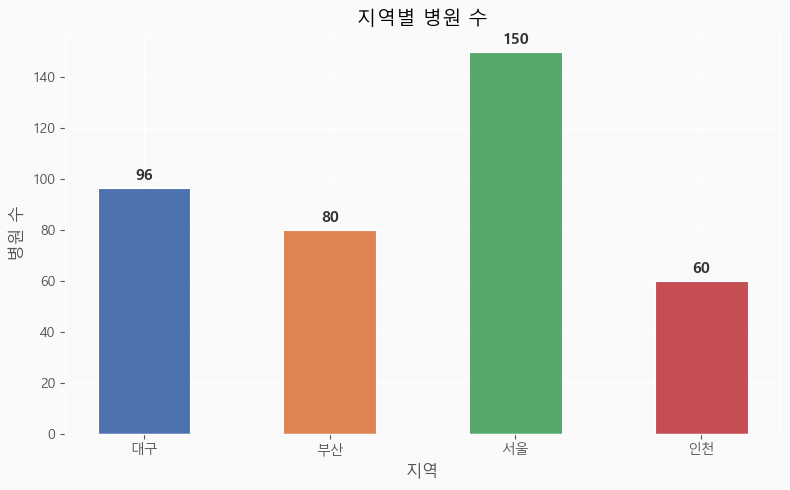

In [23]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 스타일은 bar 전에 넣는 게 좋음
plt.style.use('ggplot')


# ─── 색상 팔레트 ─────────────────────────────────────
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']   # 커스텀 팔레트

# ─── 캔버스 생성 ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#FAFAFA')       # 전체 배경
ax.set_facecolor('#FAFAFA')              # 플롯 배경

# ─── 막대 그래프 ─────────────────────────────────────
bars = ax.bar(
    merged['지역'],
    merged['병원수'],
    width=0.5,
    color=COLORS[:len(merged)],
    edgecolor='white',
    linewidth=0.8,
)


# 막대 그래프 (한 번만!)
# bars = plt.bar(
#     merged['지역'],
#     merged['병원수'],
#     width=0.5,
#     edgecolor='black',
#     linewidth=0.5,
#     alpha=0.8
# )

# 값 표시
# for bar in bars:
#     height = bar.get_height()
#     plt.text(
#         bar.get_x() + bar.get_width()/2,
#         height + 3,
#         int(height),
#         ha='center'
#     )

# ─── 데이터 레이블 ───────────────────────────────────
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.5,
        f'{int(height):,}',             # 천 단위 콤마
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        color='#333333',
    )

plt.title('지역별 병원 수', fontsize=14)
plt.xlabel('지역')
plt.ylabel('병원 수')

plt.tight_layout()
plt.show()

In [25]:
!jupyter nbconvert --to html otTest.ipynb

This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    Execute the notebook prior to export.
    Equivalent to: [--ExecutePr

[NbConvertApp] WARNING | pattern 'otTest.ipynb' matched no files
